<a href="https://colab.research.google.com/github/archangel2006/Quantinel/blob/main/classical_intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classical Intrusion Detection**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# !pip install xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import roc_curve

import joblib


In [3]:
# Load NSL-KDD

cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty_level"
]

train = pd.read_csv("KDDTrain+.txt", header=None, names=cols)
test = pd.read_csv("KDDTest+.txt", header=None, names=cols)

print("Train:", train.shape)
print("Test :", test.shape)

Train: (125973, 43)
Test : (22544, 43)


In [50]:
train.to_csv("KDDTrain.csv", index=False)

test.to_csv("KDDTest.csv", index=False)

print("CSV files saved successfully.")

CSV files saved successfully.


### **Create Binary Target**

In [4]:
def make_binary_target(df):
    df = df.copy()

    df["target"] = np.where(
        df["label"] == "normal",
        "normal",
        "attack"
    )

    return df

df_train = make_binary_target(train)
df_test = make_binary_target(test)

### **Feature/Target Split**

In [5]:
drop_cols = ["label", "difficulty_level"]

x_train = df_train.drop(
    columns=drop_cols + ["target"]
)

y_train = df_train["target"]

x_test = df_test.drop(
    columns=drop_cols + ["target"]
)

y_test = df_test["target"]

print(x_train.shape)
print(x_test.shape)

(125973, 41)
(22544, 41)


### **Encode Labels**

In [6]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(le.classes_)

['attack' 'normal']


### **Dataset Checks**

In [7]:
print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
target
normal    67343
attack    58630
Name: count, dtype: int64

Testing Class Distribution
target
attack    12833
normal     9711
Name: count, dtype: int64


### **Preprocessing**

In [8]:
cat_cols = [
    "protocol_type",
    "service",
    "flag"
]

num_cols = [
    c for c in x_train.columns
    if c not in cat_cols
]

preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ]
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ]
)

preprocessor_svm = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ]
)

# **Logistic Regression**

In [9]:
lr_model = Pipeline([
    ("preprocess", preprocessor_lr),
    (
        "clf",
        LogisticRegression(
            max_iter=1000
        )
    )
])

lr_model.fit(
    x_train,
    y_train_enc
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [10]:
print(lr_model.named_steps["clf"].n_features_in_)

print(
    lr_model.named_steps["preprocess"]
    .transform(x_test)
    .shape
)

122
(22544, 122)


# **Random Forest**

In [11]:
rf_model = Pipeline([
    ("preprocess", preprocessor_rf),
    (
        "clf",
        RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(
    x_train,
    y_train_enc
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...])])),
                ('clf',
                 RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                        random_state=42))])

# **Classical SVM**

In [12]:
svm_model = Pipeline([
    ("preprocess", preprocessor_svm),
    (
        "clf",
        SVC(
            kernel="rbf",
            probability=True
        )
    )
])

# SVM is expensive
subset = 10000

svm_model.fit(
    x_train.iloc[:subset],
    y_train_enc[:subset]
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...])])),
                ('clf', SVC(probability=True))])

**Model Checks**

In [13]:
pred = lr_model.predict(x_test)
print(pred[:10])

[0 0 1 0 1 1 1 1 1 1]


In [14]:
print(id(lr_model.named_steps["preprocess"]))
print(id(rf_model.named_steps["preprocess"]))
print(id(svm_model.named_steps["preprocess"]))

133065270961568
133065036751088
133065036747776


In [15]:
print(
    lr_model.named_steps["preprocess"]
    .transform(x_test)
    .shape
)

print(
    rf_model.named_steps["preprocess"]
    .transform(x_test)
    .shape
)

print(
    svm_model.named_steps["preprocess"]
    .transform(x_test)
    .shape
)

(22544, 122)
(22544, 122)
(22544, 116)


In [16]:
print(type(x_test))
print(x_test.shape)

<class 'pandas.core.frame.DataFrame'>
(22544, 41)


## **Evaluation Function & Results**

In [17]:
def evaluate_model(
    name,
    model,
    X,
    y_true
):

    pred = model.predict(X)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(
            y_true,
            pred,
            pos_label=0
        ),
        "Recall": recall_score(
            y_true,
            pred,
            pos_label=0
        ),
        "F1": f1_score(
            y_true,
            pred,
            pos_label=0
        )
    }

    return metrics

In [18]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_model,
        x_test,
        y_test_enc
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        x_test,
        y_test_enc
    )
)

results.append(
    evaluate_model(
        "SVM",
        svm_model,
        x_test,
        y_test_enc
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.753460,0.917480,0.622925,0.742040
1,Random Forest,0.777857,0.969181,0.629783,0.763461
2,SVM,0.771070,0.966440,0.619341,0.754903


In [19]:
# Random Forest Detailed Report

pred_rf = rf_model.predict(x_test)

print(
    classification_report(
        y_test_enc,
        pred_rf,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      attack       0.97      0.63      0.76     12833
      normal       0.67      0.97      0.79      9711

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



### **Confusion Matrix**

In [20]:
cm = confusion_matrix(
    y_test_enc,
    pred_rf
)

print(cm)

[[8082 4751]
 [ 257 9454]]


# **ROC AUC**

In [21]:
pred_prob = rf_model.predict_proba(
    x_test
)[:, 1]

auc = roc_auc_score(
    y_test_enc,
    pred_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9624261391091823


### **Why ROC-AUC is 0.96 but accuracy is 0.77?**


Accuracy = 0.77

ROC-AUC = 0.96

---

That means:
- model ranks attack traffic very well
- probability estimates are good
- thresholding is causing many mistakes

The model is learning meaningful patterns.

It is not randomly guessing.

# **Diagnostic Experiment**

In [22]:
df_all = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

X = df_all.drop(
    columns=[
        "label",
        "difficulty_level",
        "target"
    ]
)

y = df_all["target"]

y_enc = le.fit_transform(y)

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

In [27]:
# Train RF on Random Split

rf_random = Pipeline([
    ("preprocess", preprocessor_rf),
    (
        "clf",
        RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_random.fit(
    X_train_split,
    y_train_split
)

pred = rf_random.predict(
    X_test_split
)

print(
    classification_report(
        y_test_split,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     14293
           1       1.00      1.00      1.00     15411

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



### **Dataset Checks & Inferences**

In [28]:
print(df_train["label"].nunique())
print(df_test["label"].nunique())

print(
    set(df_test["label"]) -
    set(df_train["label"])
)

23
38
{'mailbomb', 'processtable', 'xsnoop', 'worm', 'mscan', 'snmpguess', 'sqlattack', 'snmpgetattack', 'apache2', 'sendmail', 'httptunnel', 'named', 'saint', 'xlock', 'udpstorm', 'xterm', 'ps'}


In [29]:
xgb_model = Pipeline([
    ("preprocess", preprocessor_rf),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(x_train, y_train_enc)

pred = xgb_model.predict(x_test)

print(
    classification_report(
        y_test_enc,
        pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      attack       0.97      0.65      0.78     12833
      normal       0.68      0.97      0.80      9711

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



Performance is evaluated on the official NSL-KDD train/test split containing previously unseen attack categories, making the task substantially harder than random train-test splitting.

# **Conclusion**

The objective of Phase 1 was to develop a classical machine learning intrusion detection pipeline capable of distinguishing malicious network traffic from normal traffic.


| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | ~75%     |
| Random Forest       | ~78%     |
| SVM                 | ~77%     |
| XGBoost             | ~79%     |




- **XGBoost** achieved the highest overall classification accuracy **(~79%)**.
- **Random Forest** achieved a high **ROC-AUC score of 0.9624**, indicating strong discrimination between attack and normal traffic.
- All models achieved **high precision (>90%)** for attack detection, suggesting that detected attacks are generally reliable.
- **Recall** values were comparatively lower, indicating that some attack instances remain difficult to identify.
- Performance is evaluated on the **official NSL-KDD train-test split**, which contains attack categories not present in the training data.

# **Sample Tests**

In [30]:
def intrusion_detection(sample_df):

    pred = rf_model.predict(sample_df)[0]

    probs = rf_model.predict_proba(sample_df)[0]

    confidence = round(
        np.max(probs) * 100,
        2
    )

    prediction = (
        "Attack"
        if pred == 0
        else "Normal"
    )

    return {
        "Prediction": prediction,
        "Confidence (%)": confidence
    }

In [31]:
sample = x_test.iloc[[0]]

result = intrusion_detection(sample)

print(result)

{'Prediction': 'Attack', 'Confidence (%)': np.float64(100.0)}


In [32]:
for i in range(5):

    sample = x_test.iloc[[i]]

    result = intrusion_detection(sample)

    print(
        f"Row {i}:",
        result
    )

Row 0: {'Prediction': 'Attack', 'Confidence (%)': np.float64(100.0)}
Row 1: {'Prediction': 'Attack', 'Confidence (%)': np.float64(100.0)}
Row 2: {'Prediction': 'Normal', 'Confidence (%)': np.float64(99.6)}
Row 3: {'Prediction': 'Attack', 'Confidence (%)': np.float64(95.28)}
Row 4: {'Prediction': 'Normal', 'Confidence (%)': np.float64(67.0)}


In [33]:
demo_csv = x_test.head(10)

demo_csv.to_csv(
    "sample_network_traffic.csv",
    index=False
)

In [34]:
def analyze_csv(csv_path):

    df = pd.read_csv(csv_path)

    preds = rf_model.predict(df)

    probs = rf_model.predict_proba(df)

    results = []

    for i in range(len(df)):

        label = (
            "Attack"
            if preds[i] == 0
            else "Normal"
        )

        confidence = round(
            np.max(probs[i]) * 100,
            2
        )

        results.append({
            "Row": i,
            "Prediction": label,
            "Confidence": confidence
        })

    return pd.DataFrame(results)

In [38]:
analyze_csv(
    "sample_network_traffic.csv"
)

,Row,Prediction,Confidence
0,0,Attack,100.00
1,1,Attack,100.00
2,2,Normal,99.60
3,3,Attack,95.28
4,4,Normal,67.00
5,5,Normal,100.00
6,6,Normal,97.40
7,7,Normal,89.40
8,8,Normal,100.00
9,9,Normal,90.40


## **Downloads**

In [44]:
# Model Comparison Table

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

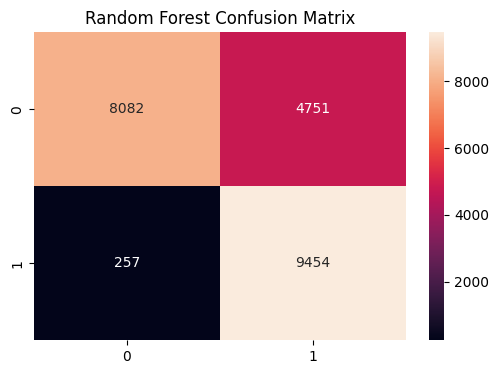

In [43]:
# Confusion Matrix

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

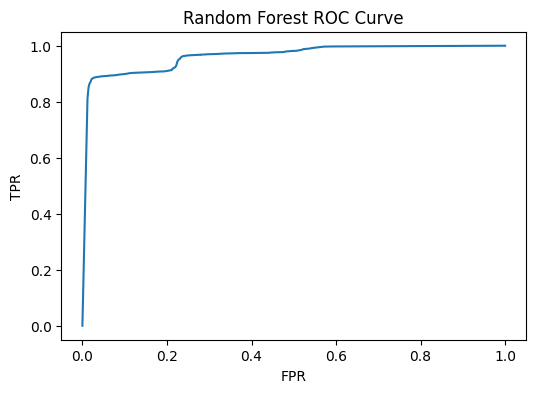

In [42]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test_enc, pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Random Forest ROC Curve")
plt.savefig("roc_curve.png")
plt.show()

In [45]:
# Unseen Attack List

unseen_attacks = sorted(
    set(df_test["label"])
    - set(df_train["label"])
)

print(unseen_attacks)

['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [46]:
pd.DataFrame(
    unseen_attacks,
    columns=["Unseen_Attack"]
).to_csv(
    "unseen_attacks.csv",
    index=False
)

In [47]:
# Best Classical Model

joblib.dump(rf_model,"random_forest.pkl")

['random_forest.pkl']

In [48]:
# Label Encoder

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']